In [1]:
import numpy as np
import jax
import jax.numpy as jnp
from functools import partial
from scipy.optimize import minimize
import casadi as cs
import time
import jax.numpy as jnp
from jaxopt import OSQP
class System:
    def __init__(self, name, mass, dt):
        self.system_name = name
        self.system_mass = mass
        self.system_dt = dt  # integrator timestep
        self.controller_type = None
        # Optional element-wise control bounds (set via `set_control_limits`).
        # Each should be an array-like of length equal to the number of inputs.
        self.u_min = None  # lower saturation limits
        self.u_max = None  # upper saturation limits
    def set_controller(self, controller_type):
        self.controller_type = controller_type
    # --------------------------------------------------------------
    # Utility: configure element-wise control saturation limits
    # --------------------------------------------------------------
    def set_control_limits(self, u_min=None, u_max=None):
        """Assign per-input control bounds used by controllers.
        Parameters
        ----------
        u_min, u_max : array-like or None
            Lower/upper limits (same shape as the control vector).  Pass
            ``None`` to leave one side unbounded.
        """
        if u_min is not None:
            self.u_min = jnp.array(u_min, dtype=float)
        if u_max is not None:
            self.u_max = jnp.array(u_max, dtype=float)
    def nominal_control(self, x, *args, **kwargs):
        if self.controller_type == "P":
            return self.p_controller(x, *args, **kwargs)
        elif self.controller_type == "LQR":
            return self.lqr_controller(x, *args, **kwargs)
        else:
            raise NotImplementedError(f"Controller {self.controller_type} not implemented for {self.system_name}.")
    def p_controller(self, x, *args, **kwargs):
        raise NotImplementedError("P controller not implemented for this system.")
    def lqr_controller(self, x, *args, **kwargs):
        raise NotImplementedError("LQR controller not implemented for this system.")
    @staticmethod
    def rk4_step(f, x, params, dt):
        k1 = f(x)
        k2 = f(x + 0.5 * dt * k1)
        k3 = f(x + 0.5 * dt * k2)
        k4 = f(x + dt * k3)
        return x + dt * (k1 + 2 * k2 + 2 * k3 + k4) / 6.0
    # def LQR too
class Quadrotor3D(System):
    """
    12‑state, 4‑input rigid‑body quadrotor (x in ℝ¹², u in ℝ⁴).
    State order:
        x = [φ, θ, ψ, p, q, r, vx, vy, vz, px, py, pz]
    Input:
        u = [ft, τx, τy, τz]   (total thrust in body‑Z and body torques)
    Disturbance / bias forces & torques are passed in as a 6‑tuple:
        d = (f_wx, f_wy, f_wz, τ_wx, τ_wy, τ_wz)
        (Set all zero for a clean rigid‑body model.)
    """
    def __init__(
            self,
            mass: float,
            gravity: float,
            arm_length: float,  # retained for API symmetry; not used directly here
            moments_of_inertia: tuple,  # (Ix, Iy, Iz)
            dt: float = 0.02,
    ):
        super().__init__("Quadrotor3D", mass, dt)
        self.gravity = float(gravity)
        self.arm_length = float(arm_length)
        self.Ix, self.Iy, self.Iz = map(float, moments_of_inertia)
        # cache for symbolic CBF terms keyed by (centre_x, centre_y, centre_z, radius)
        self._cbf_cache: dict[tuple, tuple] = {}
        self._cbf_opti_built = False  # will hold reusable Opti once built
        # -----------------------------------------------------------------
        # CBF / QP runtime buffers (filled lazily on first use) ------------
        # -----------------------------------------------------------------
        self._cbf_W = np.diag([1, 1, 1, 1])  # default QP weights
        # timing for frequency estimation
        self._cbf_last_t = None
        # Pre-compile JIT functions for better performance
        self._jit_race_ode = jax.jit(self.race_ode)
        self._jit_calc_forces = jax.jit(self.calc_forces)
        self._jit_rk4_step = jax.jit(self.rk4_step_static)
    # -----------------------------------------------------------------
    # Non‑linear continuous‑time dynamics  ẋ = f(x, u, d)
    # -----------------------------------------------------------------
    @partial(jax.jit, static_argnums=0)
    def race_ode(self, x, u, params):
        """	write dynamics as first order ODE: dxdt = f(x(t))
            x is a 6x1 vector: [x, y, psi, vx, vy, omega]^T
            u is a 2x1 vector: [acc/pwm, steer]^T
        """
        steer = u[1]
        psi = x[2]
        vx = x[3]
        vy = x[4]
        omega = x[5]
        lf = 0.029
        lr = 0.033
        mass = 0.041
        Iz = 27.8e-6
        Ffy, Frx, Fry = self.calc_forces(x, u, params)
        dxdt = jnp.zeros(6)
        x1_dot = vx * jnp.cos(psi) - vy * jnp.sin(psi)
        x2_dot = vx * jnp.sin(psi) + vy * jnp.cos(psi)
        x3_dot = omega
        x4_dot = 1 / mass * (Frx - Ffy * jnp.sin(steer)) + vy * omega
        x5_dot = 1 / mass * (Fry + Ffy * jnp.cos(steer)) - vx * omega
        x6_dot = 1 / Iz * (Ffy * lf * jnp.cos(steer) - Fry * lr)
        return jnp.array(
            [
                x1_dot,
                x2_dot,
                x3_dot,
                x4_dot,
                x5_dot,
                x6_dot,
            ])
    @partial(jax.jit, static_argnums=0)
    def calc_forces(self, x, u, params):
        steer = u[1]
        psi = x[2]
        vx = x[3]
        vy = x[4]
        omega = x[5]
        Cm1 = 0.287
        Cm2 = 0.0545
        Cr0 = 0.0518
        Cr2 = 0.00035
        lf = 0.029
        lr = 0.033
        mass = 0.041
        Iz = 27.8e-6
        Bf, Cf, Df, Br, Cr, Dr = params
        pwm = u[0]
        Frx = (Cm1 - Cm2 * vx) * pwm - Cr0 - Cr2 * (vx ** 2)
        alphaf = steer - jnp.arctan2((lf * omega + vy), jnp.abs(vx))
        alphar = jnp.arctan2((lr * omega - vy), jnp.abs(vx))
        Ffy = Df * jnp.sin(Cf * jnp.arctan(Bf * alphaf))
        Fry = Dr * jnp.sin(Cr * jnp.arctan(Br * alphar))
        return Ffy, Frx, Fry

    @partial(jax.jit, static_argnums=0)
    def batch_rk4_step(self, x, u, model_bank, dt):
        """
        Vectorized, JIT-compiled RK4 step for multiple uncertainty models.
        Parameters
        ----------
        x : jnp.ndarray, shape (12,)
            Current state
        u : jnp.ndarray, shape (4,)
            Control input
        model_bank : jnp.ndarray, shape (N_models, 6)
            Disturbance parameters for each model (f_wx, f_wy, f_wz, τ_wx, τ_wy, τ_wz)
        dt : float
            Time step
        Returns
        -------
        next_states : jnp.ndarray, shape (N_models, 12)
            Predicted next states for each model
        """
        def ode_fn(x_state, params):
            return self.race_ode(x_state, u, params)
        def rk4(params):
            k1 = ode_fn(x, params)
            k2 = ode_fn(x + 0.5 * dt * k1, params)
            k3 = ode_fn(x + 0.5 * dt * k2, params)
            k4 = ode_fn(x + dt * k3, params)
            return x + dt * (k1 + 2 * k2 + 2 * k3 + k4) / 6.0
        # Vectorize over all candidate disturbance parameters
        return jax.vmap(rk4)(model_bank)
    @staticmethod
    @partial(jax.jit, static_argnums=(0, 3))
    def rk4_step_static(f, x, params, dt):
        """Static JIT-compiled RK4 step for better performance"""
        k1 = f(x, params)
        k2 = f(x + 0.5 * dt * k1, params)
        k3 = f(x + 0.5 * dt * k2, params)
        k4 = f(x + dt * k3, params)
        return x + dt * (k1 + 2 * k2 + 2 * k3 + k4) / 6.0
    
    @partial(jax.jit, static_argnums=0)
    def fast_batch_predict(self, x, u, model_bank, dt):
        """
        Optimized batch prediction using Euler integration for speed.
        This is much faster than RK4 for large model banks.
        """
        def euler_step(params):
            return x + dt * self.race_ode(x, u, params)
        return jax.vmap(euler_step)(model_bank)
    @partial(jax.jit, static_argnums=0)
    def compute_errors(self, predictions, true_state):
        """
        Compute MSE errors for all model predictions.
        """
        diff = predictions - true_state
        return jnp.mean((diff**2), axis=1)

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


entered loop
Timestep: 0
theta_true: (0.1, 0, 0, 0, 0, 0)
theta_controller: (0.0, 0.0, 0.0, 0.0, 0.0, 0.0)
theta_controller: [-2.1807983  -0.70915043  0.1165589  -1.4363397  -0.10548366 -0.09690093]
       1: 1 Hz (inst), 1 Hz (EMA)
entered loop
Timestep: 1
theta_true: (0.1, 0, 0, 0, 0, 0)
theta_controller: [-2.1807983  -0.70915043  0.1165589  -1.4363397  -0.10548366 -0.09690093]
theta_controller: [-0.01193233  0.00834001 -0.00386674 -2.6395063  -0.25912985  0.02136388]
       2: 35 Hz (inst), 35 Hz (EMA)
entered loop
Timestep: 2
theta_true: (0.1, 0, 0, 0, 0, 0)
theta_controller: [-0.01193233  0.00834001 -0.00386674 -2.6395063  -0.25912985  0.02136388]
theta_controller: [-0.01193233  0.00834001 -0.00386674 -2.6395063  -0.25912985  0.02136388]
       3: 33 Hz (inst), 33 Hz (EMA)
entered loop
Timestep: 3
theta_true: (0.1, 0, 0, 0, 0, 0)
theta_controller: [-0.01193233  0.00834001 -0.00386674 -2.6395063  -0.25912985  0.02136388]
theta_controller: [-0.01193233  0.00834001 -0.00386674 -2.639

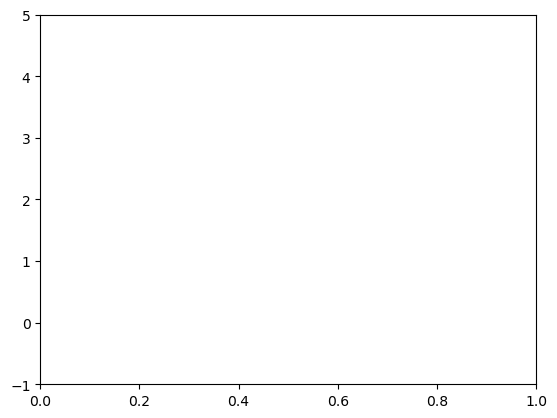

In [2]:
import numpy as np, scipy.linalg as la
from control import dlqr, dare           # pip install control
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import plotly.graph_objects as go
import random
import copy
import jax.numpy as jnp
from functools import partial
from time import perf_counter_ns
# ------------------------------------------------------------------
# 1)  model  -------------------------------------------------------
g, m, l = 9.81, 0.041, 0.3         # gravity, mass, arm-length
dt      = 0.02                   # 50 Hz integrator
N_MODELS = 30000  # Smaller for better convergence
Lookback_W = 15
MODEL_BANK = []
MODEL_PARAMS = []
#bank creation
theta_true = (0.0, 0.0, 0.0, 0.0, 0.0, 0.0)
theta_controller = (0.0, 0.0, 0.0, 0.0, 0.0, 0.0)  # Start with zero estimate
Bf = 2.579
Cf = 1.2
Df = 0.192
Br = 3.3852
Cr = 1.2691
Dr = 0.1737
initial_uncertainty = (Bf, Cf, Df, Br, Cr, Dr)
for i in range(N_MODELS):
    theta_variation = list(theta_controller)
    for k in range(len(initial_uncertainty)):
        theta_variation[k] = list(initial_uncertainty)[k] * random.uniform(-1, 1)
    MODEL_BANK.append(theta_variation)
#create quadrotor system
race_system = Quadrotor3D(m, g, l, (0, 0, 0), dt)
# @jax.jit
# def f_and_A(x, u, theta):
#     f = race_system.race_ode(x, u, theta)
#     A = jax.jacfwd(lambda x_: race_system.race_ode(x_, u, theta))(x)
#     return f, A           # (12,), (12,12)
# -------------------------------------------------------------------
# JAX-accelerated model-bank update that works with BODY-frame θ
# -------------------------------------------------------------------
@jax.jit           # only 'ptr' is static
def bank_step(x_k,               # (12,)     current state
              next_state,        # (12,)     true next state
              u_safe,            # (4,)      control used
              error_window,      # (N_mod,W) running MSE window
              ptr,               # int       circular-buffer index
              model_bank):       # (N_mod,6) BODY-frame θ candidates
    """
    Returns updated (error_window, ptr, theta_controller, best_idx)
    """
    # 1) parallel RK4 predictions with BODY-frame disturbances
    pred = race_system.batch_rk4_step(x_k, u_safe, model_bank, dt)   # (N_mod,12)
    # f0, A = jax.vmap(f_and_A, in_axes=(None, None, 0))(x_k, u_safe, model_bank)
    # pred = x_k + dt * f0 + 0.5 * (dt**2) * (A @ f0[...,None]).squeeze(-1)
    # 2) scaled MSE
    diff  = pred - next_state
    error = jnp.mean((diff**2), axis=1)             # (N_mod,)
    # 3) insert new column in sliding window
    error_window = error_window.at[:, ptr].set(error)
    # after writing the new column
    ptr = (ptr + 1) % Lookback_W
    # how many columns currently contain *real* data
    filled = jnp.where(ptr == 0, Lookback_W, ptr)
    avg_err = jnp.sum(error_window, axis=1) / filled
    best_idx = jnp.argmin(avg_err)
    theta_controller = model_bank[best_idx]
    return error_window, ptr, theta_controller, best_idx


# ------------------------------------------------------------------
# 4)  simulate 10 s  ----------------------------------------------
T_final = 10
N       = int(T_final/dt) + 1
time    = dt*np.arange(N)
X = np.zeros((N, 6))
U = np.zeros((N-1, 2))
# error_window = np.zeros((N_MODELS, Lookback_W))
error_window = jnp.zeros((N_MODELS, Lookback_W))
ptr = 0
window_count = 0
current_model_idx = 0
x0      = np.array([0, 0, 0,   0, 0, 0])
X[0] = x0
pred_param_hist = np.zeros((N - 1, 6))
true_param_hist = np.zeros((N - 1, 6))
chosen_model_hist = np.zeros(N - 1)  # Track which model was chosen at each timestep
model_bank_jax = jnp.array(MODEL_BANK, dtype=jnp.float32)
pc = perf_counter_ns
for k in range(N-1):
    t0 = pc()
    U[k] = k*0.001
    current_attitude = tuple(X[k, 0:3])             # φ, θ, ψ at time-k
    if k >= 0 and k < 100:
        wind_speed = 5  # m/s
        wind_angle = 10  # degrees
        wind_elevation = 20
        theta_true = (.1, 0, 0, 0, 0, 0)
    print("entered loop")
    print("Timestep:", k)
    print("theta_true:", theta_true)
    print("theta_controller:", theta_controller)
    #integrate one step with u_nom (no CBF)
    ode = lambda x: race_system.race_ode(x, U[k,:], theta_true)
    next_state = race_system.rk4_step(ode, X[k], theta_true, dt)
    error_window, ptr, theta_controller, current_model_idx = bank_step(
     X[k], next_state, U[k,:],
     error_window, ptr, model_bank_jax)
    print("theta_controller:", theta_controller)
    # Track which model was chosen
    chosen_model_hist[k] = current_model_idx
    pred_param_hist[k, :] = theta_controller
    true_param_hist[k, :] = theta_true
    X[k+1] = next_state
    DTT = pc() - t0  # ns
    f = 1e9 / DTT if dt else float("inf")  # Hz
    freq_ema = f
    if (k + 1) % 1 == 0:
        print(f"{k+1:>8}: {f:,.0f} Hz (inst), {freq_ema:,.0f} Hz (EMA)")
plt.ylim(-1,5)
plt.show()